# Financials EDA
Explore fundamental data fetched from Polygon and stored in S3.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
load_dotenv('../.env')

from algotrading.infra.s3_client import S3Client

s3 = S3Client(prefix='algotrading/prod')

## 1. Load data

In [2]:
TICKERS = ['AAPL', 'MSFT', 'JPM', 'XOM', 'JNJ']

df = s3.read_financials(TICKERS)
print(f'Shape: {df.shape}')
df.head()

Shape: (143, 100)


,ticker,period_start_date,period_end_date,filing_date,timeframe,fiscal_year,fiscal_period,income_statement__revenues,income_statement__benefits_costs_expenses,income_statement__costs_and_expenses,...,balance_sheet__cash,income_statement__interest_and_debt_expense,income_statement__noninterest_expense,income_statement__noninterest_income,income_statement__income_loss_from_discontinued_operations_net_of_tax_during_phase_out,balance_sheet__redeemable_noncontrolling_interest_other,income_statement__gain_loss_on_sale_properties_net_tax,income_statement__income_loss_from_discontinued_operations_net_of_tax_provision_for_gain_loss_on_disposal,balance_sheet__redeemable_noncontrolling_interest_common,balance_sheet__redeemable_noncontrolling_interest_preferred
0,AAPL,2015-09-27,2015-12-26,2016-01-27,quarterly,2016,Q1,7.587200e+10,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AAPL,2015-12-27,2016-03-26,2016-04-27,quarterly,2016,Q2,5.055700e+10,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AAPL,2016-03-27,2016-06-25,2016-07-27,quarterly,2016,Q3,4.235800e+10,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AAPL,2016-09-25,2016-12-31,2017-02-01,quarterly,2017,Q1,7.835100e+10,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AAPL,2017-01-01,2017-04-01,2017-05-03,quarterly,2017,Q2,5.289600e+10,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Schema overview

In [4]:
# Group columns by statement
meta_cols = ['ticker', 'period_start_date', 'period_end_date', 'filing_date', 'timeframe', 'fiscal_year', 'fiscal_period']
income_cols = [c for c in df.columns if c.startswith('income_statement__')]
balance_cols = [c for c in df.columns if c.startswith('balance_sheet__')]
cashflow_cols = [c for c in df.columns if c.startswith('cash_flow_statement__')]

print(f'Meta columns:         {len(meta_cols)}')
print(f'Income statement:     {len(income_cols)}')
print(f'Balance sheet:        {len(balance_cols)}')
print(f'Cash flow statement:  {len(cashflow_cols)}')
print()
print('Income statement fields:')
for c in income_cols:
    print(f'  {c.replace("income_statement__", "")}')

Meta columns:         7
Income statement:     49
Balance sheet:        31
Cash flow statement:  13

Income statement fields:
  revenues
  benefits_costs_expenses
  costs_and_expenses
  operating_expenses
  depreciation_and_amortization
  other_operating_expenses
  operating_income_loss
  income_loss_from_continuing_operations_after_tax
  income_loss_from_continuing_operations_before_tax
  income_tax_expense_benefit
  interest_expense_operating
  net_income_loss
  net_income_loss_attributable_to_noncontrolling_interest
  net_income_loss_attributable_to_parent
  net_income_loss_available_to_common_stockholders_basic
  participating_securities_distributed_and_undistributed_earnings_loss_basic
  preferred_stock_dividends_and_other_adjustments
  basic_earnings_per_share
  diluted_earnings_per_share
  basic_average_shares
  diluted_average_shares
  common_stock_dividends
  income_tax_expense_benefit_deferred
  income_loss_before_equity_method_investments
  income_loss_from_equity_method_inve

In [5]:
print('Balance sheet fields:')
for c in balance_cols:
    print(f'  {c.replace("balance_sheet__", "")}')

Balance sheet fields:
  assets
  current_assets
  noncurrent_assets
  fixed_assets
  intangible_assets
  other_noncurrent_assets
  liabilities
  current_liabilities
  accounts_payable
  other_current_liabilities
  noncurrent_liabilities
  equity
  equity_attributable_to_noncontrolling_interest
  equity_attributable_to_parent
  liabilities_and_equity
  long_term_debt
  redeemable_noncontrolling_interest
  temporary_equity
  inventory
  prepaid_expenses
  other_current_assets
  other_noncurrent_liabilities
  accounts_receivable
  wages
  commitments_and_contingencies
  long_term_investments
  temporary_equity_attributable_to_parent
  cash
  redeemable_noncontrolling_interest_other
  redeemable_noncontrolling_interest_common
  redeemable_noncontrolling_interest_preferred


In [6]:
print('Cash flow fields:')
for c in cashflow_cols:
    print(f'  {c.replace("cash_flow_statement__", "")}')

Cash flow fields:
  net_cash_flow_from_operating_activities
  net_cash_flow_from_operating_activities_continuing
  net_cash_flow_from_investing_activities
  net_cash_flow_from_investing_activities_continuing
  net_cash_flow_from_financing_activities
  net_cash_flow_from_financing_activities_continuing
  net_cash_flow
  net_cash_flow_continuing
  net_cash_flow_from_operating_activities_discontinued
  net_cash_flow_from_investing_activities_discontinued
  net_cash_flow_from_financing_activities_discontinued
  net_cash_flow_discontinued
  exchange_gains_losses


## 3. Coverage — how many filings per ticker?

In [ ]:
df.groupby('ticker').agg(
    filings=('filing_date', 'count'),
    earliest=('filing_date', 'min'),
    latest=('filing_date', 'max'),
).reset_index()

## 4. Null coverage — which fields are sparse?

In [7]:
null_pct = df.isnull().mean().sort_values(ascending=False)
print('Fields with >50% nulls (sparse/unreliable):')
print(null_pct[null_pct > 0.5].to_string())
print()
print('Fields with <10% nulls (reliable):')
print(null_pct[null_pct < 0.1].to_string())

Fields with >50% nulls (sparse/unreliable):
balance_sheet__redeemable_noncontrolling_interest_preferred                                                  1.000000
balance_sheet__temporary_equity_attributable_to_parent                                                       1.000000
income_statement__cost_of_revenue_services                                                                   1.000000
balance_sheet__temporary_equity                                                                              1.000000
cash_flow_statement__net_cash_flow_from_operating_activities_discontinued                                    1.000000
cash_flow_statement__net_cash_flow_from_investing_activities_discontinued                                    1.000000
cash_flow_statement__net_cash_flow_from_financing_activities_discontinued                                    1.000000
cash_flow_statement__net_cash_flow_discontinued                                                              1.000000
balance_shee

## 5. Key income statement metrics over time

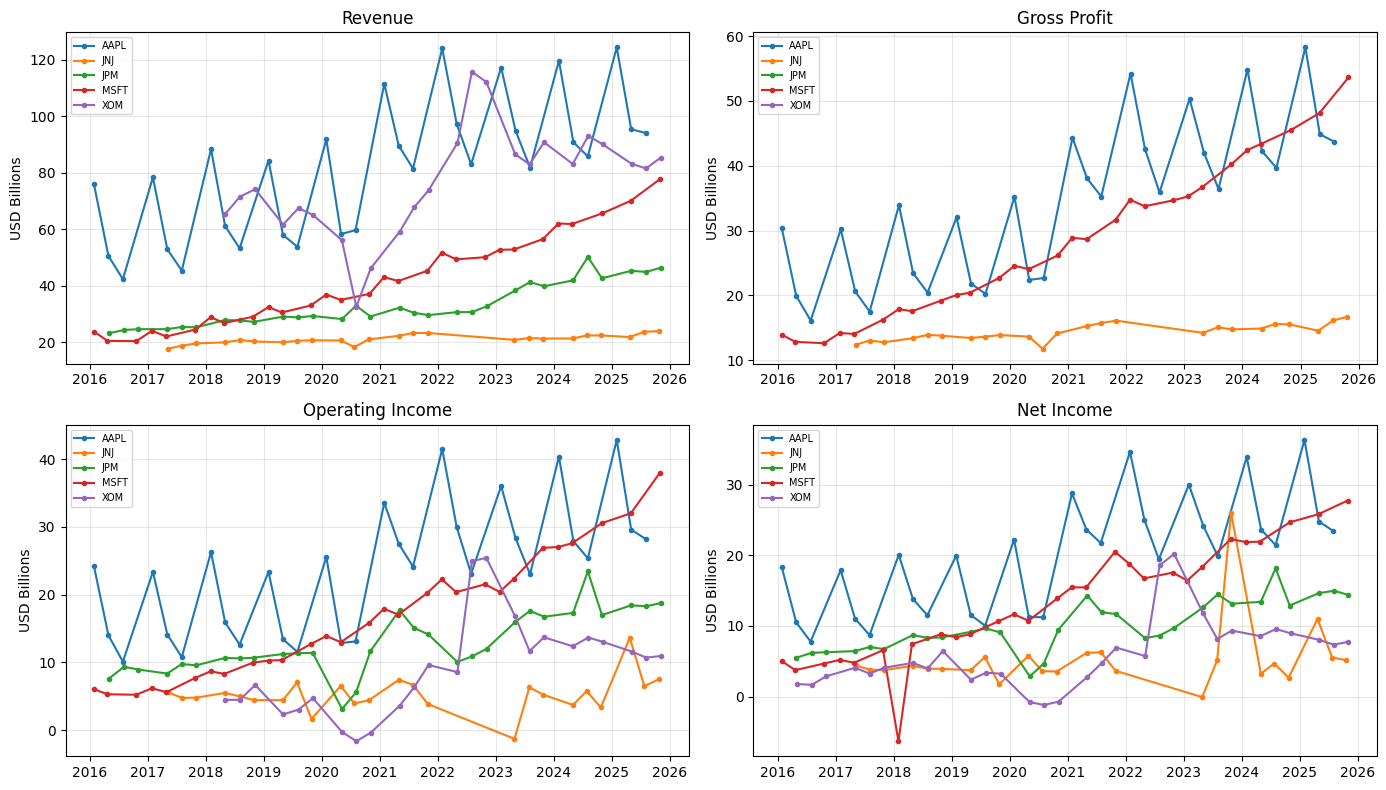

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

metrics = [
    ('income_statement__revenues', 'Revenue'),
    ('income_statement__gross_profit', 'Gross Profit'),
    ('income_statement__operating_income_loss', 'Operating Income'),
    ('income_statement__net_income_loss', 'Net Income'),
]

for ax, (col, label) in zip(axes.flat, metrics):
    for ticker, grp in df.groupby('ticker'):
        if col in grp.columns:
            ax.plot(grp['filing_date'], grp[col] / 1e9, label=ticker, marker='o', markersize=3)
    ax.set_title(label)
    ax.set_ylabel('USD Billions')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Key balance sheet metrics

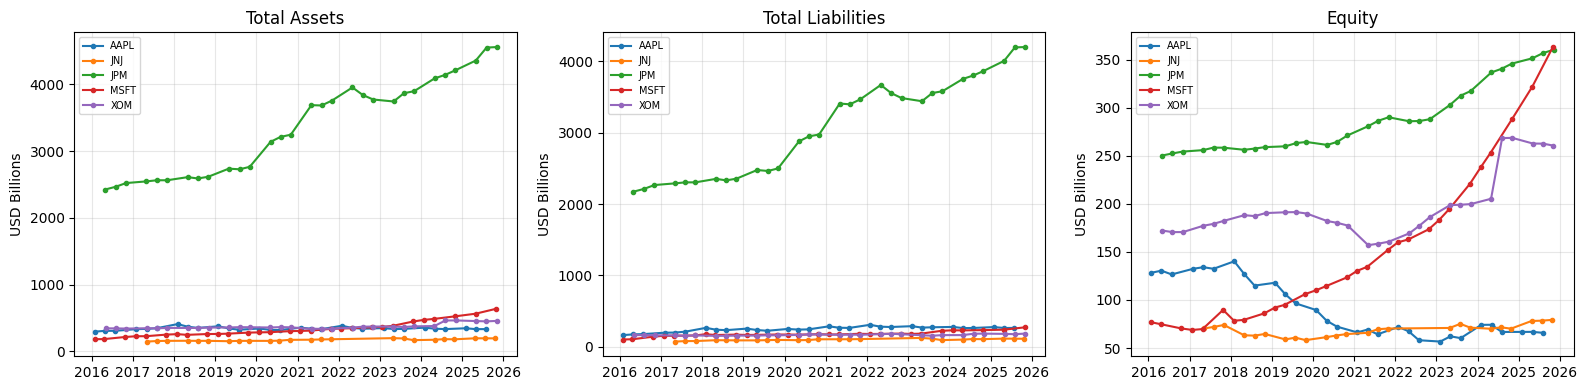

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

metrics = [
    ('balance_sheet__assets', 'Total Assets'),
    ('balance_sheet__liabilities', 'Total Liabilities'),
    ('balance_sheet__equity_attributable_to_parent', 'Equity'),
]

for ax, (col, label) in zip(axes, metrics):
    for ticker, grp in df.groupby('ticker'):
        if col in grp.columns:
            ax.plot(grp['filing_date'], grp[col] / 1e9, label=ticker, marker='o', markersize=3)
    ax.set_title(label)
    ax.set_ylabel('USD Billions')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Derived ratios — candidate signals

In [10]:
df['gross_margin'] = df['income_statement__gross_profit'] / df['income_statement__revenues']
df['operating_margin'] = df['income_statement__operating_income_loss'] / df['income_statement__revenues']
df['net_margin'] = df['income_statement__net_income_loss'] / df['income_statement__revenues']
df['roe'] = df['income_statement__net_income_loss'] / df['balance_sheet__equity_attributable_to_parent']
df['debt_to_equity'] = df['balance_sheet__long_term_debt'] / df['balance_sheet__equity_attributable_to_parent']
df['revenue_growth_yoy'] = df.groupby('ticker')['income_statement__revenues'].pct_change(4)

ratio_cols = ['ticker', 'filing_date', 'fiscal_period', 'gross_margin', 'operating_margin', 'net_margin', 'roe', 'debt_to_equity', 'revenue_growth_yoy']
df[ratio_cols].round(3)

/var/folders/pz/n51wnxpj59g9w6k9pl_ty57w0000gn/T/ipykernel_46478/3797222875.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['revenue_growth_yoy'] = df.groupby('ticker')['income_statement__revenues'].pct_change(4)
/var/folders/pz/n51wnxpj59g9w6k9pl_ty57w0000gn/T/ipykernel_46478/3797222875.py:9: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  df[ratio_cols].round(3)


,ticker,filing_date,fiscal_period,gross_margin,operating_margin,net_margin,roe,debt_to_equity,revenue_growth_yoy
0,AAPL,2016-01-27,Q1,0.401,0.319,0.242,0.143,NaN,NaN
1,AAPL,2016-04-27,Q2,0.394,0.277,0.208,0.081,NaN,NaN
2,AAPL,2016-07-27,Q3,0.380,0.239,0.184,0.062,NaN,NaN
3,AAPL,2017-02-01,Q1,0.385,0.298,0.228,0.135,NaN,NaN
4,AAPL,2017-05-03,Q2,0.389,0.267,0.209,0.082,NaN,-0.303
...,...,...,...,...,...,...,...,...,...
138,XOM,2024-08-05,Q2,NaN,0.147,0.103,0.036,NaN,0.075
139,XOM,2024-11-04,Q3,NaN,0.145,0.100,0.033,NaN,0.086
140,XOM,2025-05-05,Q1,NaN,0.140,0.097,0.031,NaN,-0.084
141,XOM,2025-08-04,Q2,NaN,0.131,0.090,0.028,NaN,-0.019


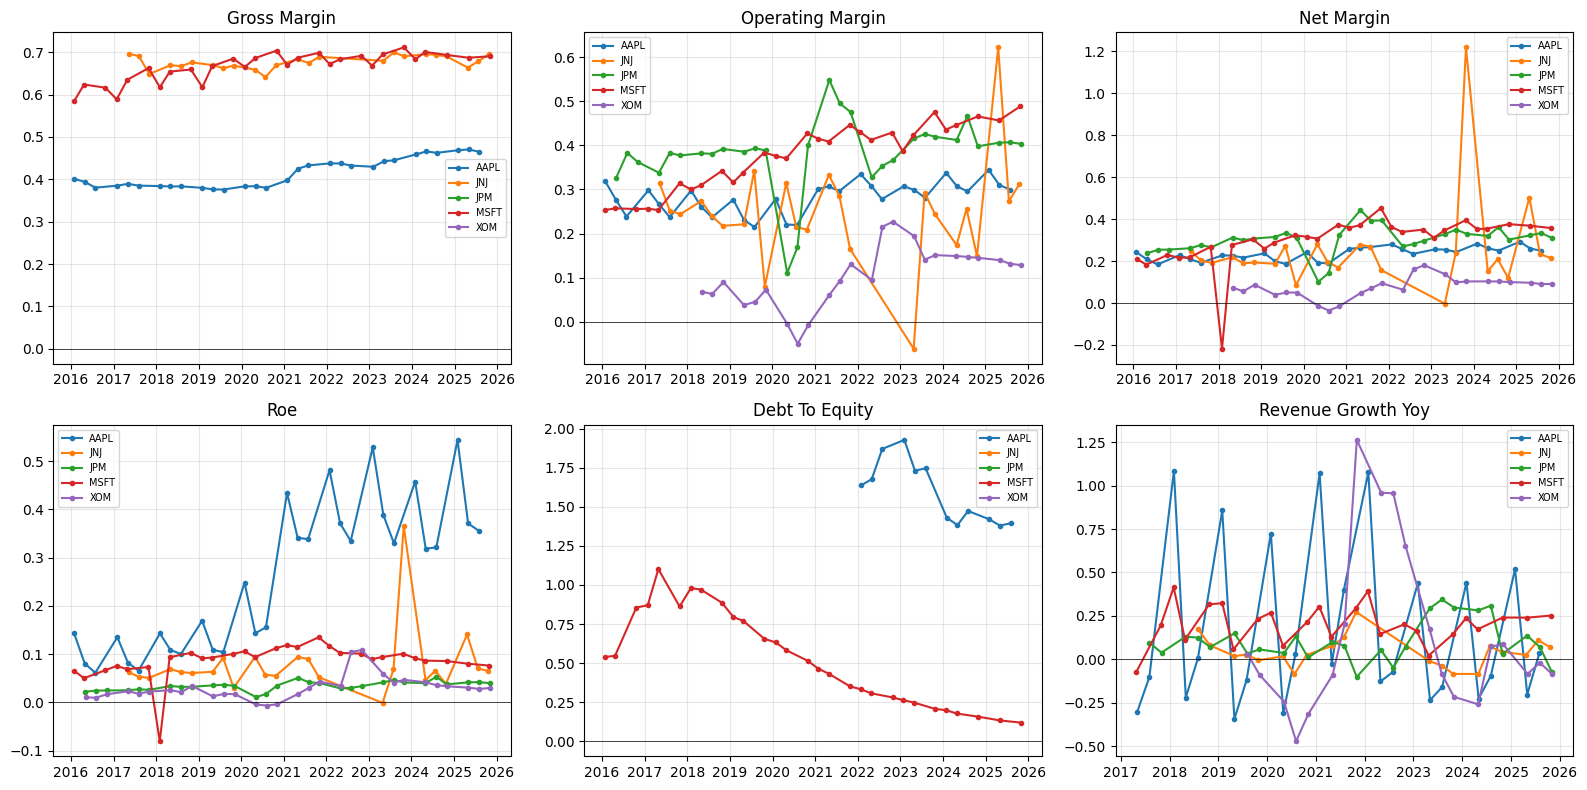

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

ratio_metrics = ['gross_margin', 'operating_margin', 'net_margin', 'roe', 'debt_to_equity', 'revenue_growth_yoy']

for ax, col in zip(axes.flat, ratio_metrics):
    for ticker, grp in df.groupby('ticker'):
        ax.plot(grp['filing_date'], grp[col], label=ticker, marker='o', markersize=3)
    ax.set_title(col.replace('_', ' ').title())
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()